# Assignment 5 — Text Classification (Track B)

**DATAX504**  
**Task:** Classify AG News into four topic classes and report test accuracy (%) for Moodle `a5_metric`.

This notebook uses **Track B — Text** only.

## AI disclosure

| Field | Your answer |
|---|---|
| Tool / model | ChatGPT (OpenAI) |
| Used for | Helping draft and revise parts of the code and written explanations, and reviewing the workflow. |
| Verified how | I ran the notebook in VS Code and checked the data split, model outputs, test accuracy and confusion matrix. |
| Not used for | Fabricating the reported accuracy or changing the data labels. |


In [1]:
# Track selection — Moodle a5_track
TRACK = "B"

import os
import re
import random
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print("Selected track:", TRACK)
print("Keras version:", keras.__version__)

Selected track: B
Keras version: 3.15.1


## 1. Load AG News

AG News has four classes: **World, Sports, Business, Sci/Tech**. The original training and test splits are kept separate. A validation set is created only from the original training split.

In [2]:
if TRACK != "B":
    raise ValueError("This completed notebook is for Track B.")

DATA_DIR = "ag_news_data"
os.makedirs(DATA_DIR, exist_ok=True)

TRAIN_URL = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"
TEST_URL = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv"
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")

def download_if_needed(url, path):
    if not os.path.exists(path):
        print(f"Downloading {os.path.basename(path)} ...")
        try:
            urllib.request.urlretrieve(url, path)
        except Exception as e:
            raise RuntimeError(
                f"Could not download {url}. Check the internet connection, then run this cell again."
            ) from e

download_if_needed(TRAIN_URL, TRAIN_PATH)
download_if_needed(TEST_URL, TEST_PATH)

columns = ["label", "title", "description"]
train_df = pd.read_csv(TRAIN_PATH, header=None, names=columns)
test_df = pd.read_csv(TEST_PATH, header=None, names=columns)

# Convert labels 1..4 to 0..3 for sparse categorical cross-entropy.
train_df["label"] = train_df["label"].astype(int) - 1
test_df["label"] = test_df["label"].astype(int) - 1

train_df["text"] = (train_df["title"].fillna("") + " " + train_df["description"].fillna("")).str.strip()
test_df["text"] = (test_df["title"].fillna("") + " " + test_df["description"].fillna("")).str.strip()

class_names = ["World", "Sports", "Business", "Sci/Tech"]

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print(train_df[["label", "title"]].head())

Training rows: 120000
Test rows: 7600
   label                                              title
0      2  Wall St. Bears Claw Back Into the Black (Reuters)
1      2  Carlyle Looks Toward Commercial Aerospace (Reu...
2      2    Oil and Economy Cloud Stocks' Outlook (Reuters)
3      2  Iraq Halts Oil Exports from Main Southern Pipe...
4      2  Oil prices soar to all-time record, posing new...


## 2. Train/validation split

The official test set is not used for model selection. I split the original training data into training and validation sets with stratification so that the four classes stay balanced.

In [3]:
X_train_text, X_val_text, y_train, y_val = train_test_split(
    train_df["text"].to_numpy(),
    train_df["label"].to_numpy(),
    test_size=0.10,
    random_state=SEED,
    stratify=train_df["label"].to_numpy(),
)

X_test_text = test_df["text"].to_numpy()
y_test = test_df["label"].to_numpy()

print("Train:", len(X_train_text))
print("Validation:", len(X_val_text))
print("Test:", len(X_test_text))

Train: 108000
Validation: 12000
Test: 7600


## 3. Tokenisation and vectorisation

The vocabulary is built **only from the training split** to avoid leakage. Index 0 is reserved for padding and index 1 for out-of-vocabulary words.

In [4]:
MAX_TOKENS = 20_000
MAX_LEN = 100
PAD_ID = 0
OOV_ID = 1

TOKEN_PATTERN = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z]+)?")

def tokenize(text):
    return TOKEN_PATTERN.findall(str(text).lower())

word_counts = Counter()
for text in X_train_text:
    word_counts.update(tokenize(text))

most_common = word_counts.most_common(MAX_TOKENS - 2)
word_to_id = {word: i + 2 for i, (word, _) in enumerate(most_common)}
VOCAB_SIZE = len(word_to_id) + 2

def encode_texts(texts, max_len=MAX_LEN):
    encoded = np.zeros((len(texts), max_len), dtype=np.int32)
    for i, text in enumerate(texts):
        ids = [word_to_id.get(token, OOV_ID) for token in tokenize(text)]
        ids = ids[:max_len]
        encoded[i, :len(ids)] = ids
    return encoded

X_train = encode_texts(X_train_text)
X_val = encode_texts(X_val_text)
X_test = encode_texts(X_test_text)

print("Vocabulary size:", VOCAB_SIZE)
print("Sequence length:", MAX_LEN)
print("X_train shape:", X_train.shape)
print("Example token IDs:", X_train[0, :20])

Vocabulary size: 20000
Sequence length: 100
X_train shape: (108000, 100)
Example token IDs: [ 132 1780   12  675 2617  373 1843 1780 3702   82  856    3 1683    4
 7612 5360    4 5814  225    2]


## 4. Build the sequence model

A bidirectional GRU is used because news classification depends on word order and context. `mask_zero=True` tells the recurrent layer to ignore padded positions.

In [5]:
model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,), dtype="int32"),
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True,
        name="embedding",
    ),
    layers.Bidirectional(layers.GRU(64), name="bidirectional_gru"),
    layers.Dropout(0.35),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(4, activation="softmax"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_gru               │ (None, 128)            │        74,496 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,643,012 (10.08 MB)

 Trainable params: 2,643,012 (10.08 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train

Early stopping keeps the weights from the epoch with the best validation accuracy and reduces unnecessary overfitting.

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        mode="max",
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
    ),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=6,
    batch_size=128,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 89s 104ms/step - accuracy: 0.8719 - loss: 0.3689 - val_accuracy: 0.9221 - val_loss: 0.2374 - learning_rate: 0.0010
Epoch 2/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 90s 106ms/step - accuracy: 0.9360 - loss: 0.1959 - val_accuracy: 0.9193 - val_loss: 0.2528 - learning_rate: 0.0010
Epoch 3/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 100ms/step - accuracy: 0.9571 - loss: 0.1270 - val_accuracy: 0.9171 - val_loss: 0.2841 - learning_rate: 5.0000e-04


## 6. Training curves

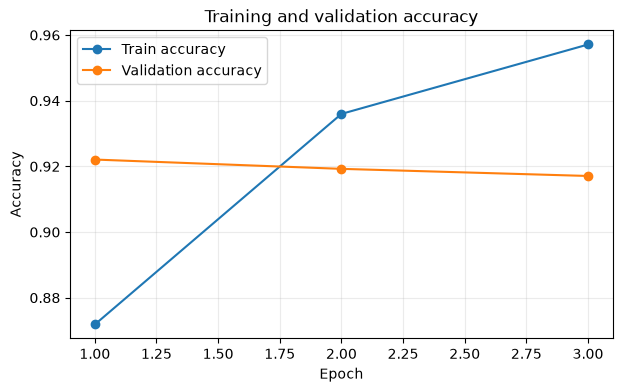

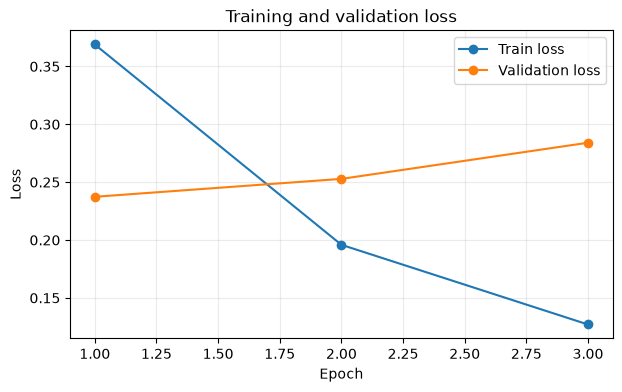

In [7]:
epochs_ran = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_ran, history.history["accuracy"], marker="o", label="Train accuracy")
plt.plot(epochs_ran, history.history["val_accuracy"], marker="o", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_ran, history.history["loss"], marker="o", label="Train loss")
plt.plot(epochs_ran, history.history["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 7. Final test evaluation

The required Moodle metric for Track B is **test accuracy as a percentage**.

In [8]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, batch_size=256, verbose=0)
metric = round(float(test_accuracy) * 100, 2)

print(f"Test loss: {test_loss:.4f}")
print(f"Track B accuracy % (Moodle a5_metric): {metric:.2f}")

Test loss: 0.2491
Track B accuracy % (Moodle a5_metric): 92.07


## 8. Error check by class

This is not required for `a5_metric`, but it helps check whether the model performs similarly across the four topics.

In [9]:
probabilities = model.predict(X_test, batch_size=256, verbose=0)
y_pred = np.argmax(probabilities, axis=1)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (rows=true, columns=predicted):")
print(pd.DataFrame(cm, index=class_names, columns=class_names))

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

Confusion matrix (rows=true, columns=predicted):
          World  Sports  Business  Sci/Tech
World      1698      54        97        51
Sports       16    1864        12         8
Business     39      13      1698       150
Sci/Tech     38      10       115      1737

Classification report:
              precision    recall  f1-score   support

       World      0.948     0.894     0.920      1900
      Sports      0.960     0.981     0.971      1900
    Business      0.883     0.894     0.889      1900
    Sci/Tech      0.893     0.914     0.903      1900

    accuracy                          0.921      7600
   macro avg      0.921     0.921     0.921      7600
weighted avg      0.921     0.921     0.921      7600



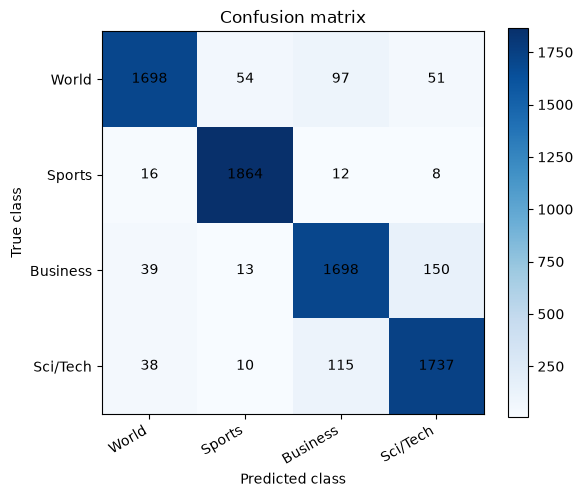

In [10]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(range(4), class_names, rotation=30, ha="right")
plt.yticks(range(4), class_names)
plt.colorbar()

for i in range(4):
    for j in range(4):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 9. Written responses

### Architecture summary — Moodle `a5_architecture` (max 100 words)

I used an Embedding layer followed by a bidirectional GRU with 64 units. The embedding learns a 128-dimensional representation for each token, while the GRU reads the sequence in both directions to capture context. Two dropout layers reduce overfitting, and a small dense layer combines the learned features. The final softmax layer has four outputs, one for each AG News class.

### Input preparation — Moodle `a5_tokenisation` (max 100 words)

I combined each news title and description, converted text to lowercase, and split it into word-like tokens with a regular expression. The vocabulary was built from the training split only, keeping the 19,998 most frequent words plus two reserved IDs for padding and unknown words. Unknown words use an OOV token. Every article was padded or truncated to 100 tokens. Padding uses index 0, which is masked by the Embedding layer so padded positions are ignored by the GRU.

## 10. Moodle fields

After running the notebook, copy the values below into Moodle. `a5_repo` is your own repository URL, so it cannot be generated from this notebook.

In [11]:
a5_track = TRACK
a5_metric = metric
a5_architecture = 'I used an Embedding layer followed by a bidirectional GRU with 64 units. The embedding learns a 128-dimensional representation for each token, while the GRU reads the sequence in both directions to capture context. Two dropout layers reduce overfitting, and a small dense layer combines the learned features. The final softmax layer has four outputs, one for each AG News class.'
a5_tokenisation = 'I combined each news title and description, converted text to lowercase, and split it into word-like tokens with a regular expression. The vocabulary was built from the training split only, keeping the 19,998 most frequent words plus two reserved IDs for padding and unknown words. Unknown words use an OOV token. Every article was padded or truncated to 100 tokens. Padding uses index 0, which is masked by the Embedding layer so padded positions are ignored by the GRU.'

print("a5_track:", a5_track)
print("a5_metric:", a5_metric)
print("\na5_architecture:\n", a5_architecture)
print("\na5_tokenisation:\n", a5_tokenisation)
print("\na5_repo: paste your own repository URL into Moodle")

a5_track: B
a5_metric: 92.07

a5_architecture:
 I used an Embedding layer followed by a bidirectional GRU with 64 units. The embedding learns a 128-dimensional representation for each token, while the GRU reads the sequence in both directions to capture context. Two dropout layers reduce overfitting, and a small dense layer combines the learned features. The final softmax layer has four outputs, one for each AG News class.

a5_tokenisation:
 I combined each news title and description, converted text to lowercase, and split it into word-like tokens with a regular expression. The vocabulary was built from the training split only, keeping the 19,998 most frequent words plus two reserved IDs for padding and unknown words. Unknown words use an OOV token. Every article was padded or truncated to 100 tokens. Padding uses index 0, which is masked by the Embedding layer so padded positions are ignored by the GRU.

a5_repo: paste your own repository URL into Moodle


### Final check before submission

Run **all cells from top to bottom** and make sure there are no errors. The final `a5_metric` must come from your own completed run, and the Moodle `a5_repo` must be your own repository link.